# Hybrid randomized carving: exact balance + conditional randomness

The [carving vs cube method comparison](carving_vs_cube_method.ipynb) exposed
a real weakness of deterministic carving: the optimum is **degenerate** (many
subsets satisfy the constraints equally well), the solver picks one by
arbitrary tie-breaking, and on attributes you *didn't* constrain the returned
subset can wander — with no theory describing the wander.

`datacarve`'s **`randomize`** parameter fixes this with a hybrid strategy:

1. the MILP still decides ***how many* rows** to take from each joint
   quantization cell — the hard combinatorial part, where optimality matters;
2. ***which* rows** fill each cell's quota is then drawn **at random** from
   that cell's members — because rows within a cell are interchangeable with
   respect to every histogram constraint.

Result: every marginal histogram is *identical* to the deterministic
solution, but the selection is now random *conditional on the constrained
attributes* — the best that any method can guarantee while imposing balance
(see the cube notebook for why unconditional randomness is incompatible with
balance). This notebook verifies both properties.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from datacarve import undersample_dataset

plt.style.use("ggplot")
rng = np.random.default_rng(7)

# same synthetic panel as the cube comparison, with a hidden attribute
N, K = 6_000, 1_500
age = np.clip(20 + np.abs(rng.normal(5, 14, N)), 18, 80)
gender = rng.choice([0.0, 1.0], N, p=[0.62, 0.38])            # 0=M, 1=F
region = rng.choice([0.0, 1.0, 2.0], N, p=[0.65, 0.25, 0.10]) # urban/sub/rural

# hidden attribute: correlated with age and region, NOT given to the carve
screen_time = 10 - 0.08 * age + 1.5 * (region == 0.0) + rng.normal(0, 1.0, N)

data = np.column_stack([gender, region])
TARGETS = dict(
    data_to_keep=K,
    target_distribution=["uniform", [45, 35, 20]],
    categorical_dims=[0, 1],
    verbose=False, scatterplot_matrix=False,
)

## 1. Same balance, guaranteed

One deterministic carve, one randomized carve. The counts must be identical —
`randomize` only redraws *within* cells.


In [2]:
det = undersample_dataset(data, **TARGETS)
rnd = undersample_dataset(data, randomize=0, **TARGETS)

def counts(mask):
    return [(gender[mask] == 1).sum(), (region[mask] == 0).sum(),
            (region[mask] == 1).sum(), (region[mask] == 2).sum()]

print(f"{'':14s}  female   urban  suburb   rural")
print(f"{'deterministic':14s}  " + "  ".join(f"{c:6d}" for c in counts(det)))
print(f"{'randomize=0':14s}  " + "  ".join(f"{c:6d}" for c in counts(rnd)))
print(f"\nsubsets share {int((det & rnd).sum())} of {K} rows "
      f"(same composition, different individuals)")

                female   urban  suburb   rural
deterministic      750     675     525     300
randomize=0        750     675     525     300

subsets share 833 of 1500 rows (same composition, different individuals)


## 2. The hidden attribute, before and after

We repeat the cube-notebook experiment: mean `screen_time` of **urban women**
in the subset, against the pool truth for that subgroup. Left: deterministic
carving rerun on shuffled row orders (the degeneracy wander). Right: hybrid
carving across 40 seeds.


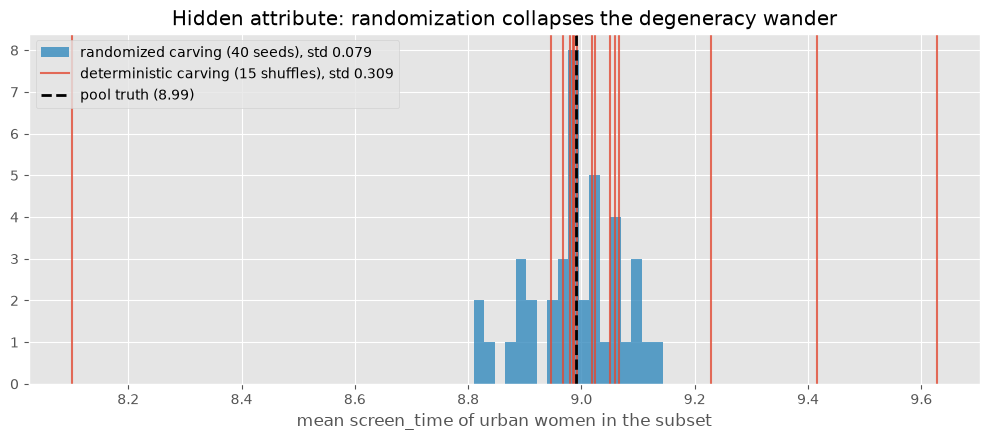

pool truth:     8.990
deterministic:  mean 9.030, std 0.309
randomized:     mean 8.989, std 0.079


In [3]:
pool_truth = screen_time[(gender == 1) & (region == 0)].mean()

def urban_women_mean(mask):
    return screen_time[mask & (gender == 1) & (region == 0)].mean()

# deterministic carving, 15 shuffled row orders (the degeneracy wander)
det_means = []
for s in range(15):
    perm = np.random.default_rng(s).permutation(N)
    m_p = undersample_dataset(data[perm], **TARGETS)
    sel = np.zeros(N, dtype=bool); sel[perm[m_p]] = True
    det_means.append(urban_women_mean(sel))
det_means = np.array(det_means)

# hybrid randomized carving, 40 seeds
rnd_means = np.array([
    urban_women_mean(undersample_dataset(data, randomize=s, **TARGETS))
    for s in range(40)
])

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(rnd_means, bins=18, color="#348ABD", alpha=0.8,
        label=f"randomized carving (40 seeds), std {rnd_means.std():.3f}")
for i, v in enumerate(det_means):
    ax.axvline(v, color="#E24A33", lw=1.5, alpha=0.8,
               label=f"deterministic carving (15 shuffles), std {det_means.std():.3f}"
               if i == 0 else None)
ax.axvline(pool_truth, color="black", lw=2, ls="--",
           label=f"pool truth ({pool_truth:.2f})")
ax.set_xlabel("mean screen_time of urban women in the subset")
ax.set_title("Hidden attribute: randomization collapses the degeneracy wander")
ax.legend()
plt.tight_layout(); plt.show()

print(f"pool truth:     {pool_truth:.3f}")
print(f"deterministic:  mean {det_means.mean():.3f}, std {det_means.std():.3f}")
print(f"randomized:     mean {rnd_means.mean():.3f}, std {rnd_means.std():.3f}")

The randomized carves concentrate tightly around the pool truth — comparable
to the cube method's valid sampling spread in the companion notebook — while
keeping the *exact* quota counts that the cube method can only hit in
expectation. The deterministic carves' wide, uncentered wander is gone,
because the arbitrary tie-breaking that caused it has been replaced by a
coin flip within each cell.

To be precise about what is and isn't guaranteed: within each constrained
cell, the draw is a simple random sample, so hidden attributes are unbiased
*conditional on the cell composition you imposed*. The composition itself
still tilts anything correlated with the constrained attributes — that's the
point of balancing — and the tilt is documented by the constraints.

## 3. Practical guidance

- **Reporting per-group metrics from a carved eval set?** Use `randomize=`
  (any seed). Same balance, and the individuals filling each quota are no
  longer an accident of your file's row order.
- **Want a spread on a downstream metric?** Draw several seeds and look at
  the variation across equivalent subsets — as done above.
- **Need the correlation-minimization objective (`lamda`) honored exactly?**
  Stay deterministic (`randomize=None`, the default): the redraw preserves
  every histogram but may be slightly off-optimum on that soft objective.

**Install:** `pip install datacarve` &nbsp;|&nbsp; **Repo:**
<https://github.com/bbonik/datacarve>
